**Problema de despacho como un juego de suma cero**

alejandro.garces@utp.edu.co

Agosto de 2026

In [1]:
## Instalar paquetes
paquetes = ["Plots", "LinearAlgebra", "JuMP", "Ipopt", "ForwardDiff"]
using Pkg
for paquete in paquetes
    if !haskey(Pkg.project().dependencies, paquete)
        @info "Instalando $paquete..."
        Pkg.add(paquete)
    end
end
for paquete in paquetes
	 @eval using $(Symbol(paquete))
end

In [12]:
# construccion de una instancia aleatoria del problema
n = 10
xopt = rand(n)
xopt = xopt./sum(xopt)
b = rand(n)*n
lopt = n
a = (-b.+lopt)./xopt

10-element Vector{Float64}:
  2.5734557804564058
 13.431858162713011
 51.67021832085055
 76.74819509331302
 14.084250852835154
 24.164208227425586
 45.553405261016074
 10.140361119688732
 74.13028966128421
 42.75488140618862

In [13]:
Despacho = Model(Ipopt.Optimizer)
@variable(Despacho, x[1:n])
@objective(Despacho,Min,sum(0.5*a.*x.^2 .+ b.*x))
@constraint(Despacho, balance, sum(x) == 1)
optimize!(Despacho)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       10
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.00e+00 5.27e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [14]:
#Optimo primal
xopt = round.(value.(x), digits=3)

10-element Vector{Float64}:
 0.104
 0.047
 0.058
 0.075
 0.012
 0.092
 0.167
 0.191
 0.051
 0.203

In [15]:
λopt = -shadow_price.(balance)

10.0

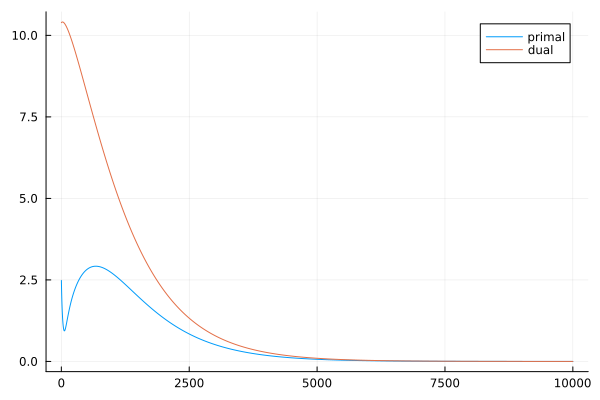

In [16]:
# modelo como un juego de suma cero con lagrangeano normal
# Jugador 1: busca minimizar L mediante el metodo del gradiente sobre las variables x
# Jugador 2: busca maximizar L mediante el metodo del gradiente sobre las variables λ
paso_primal = 0.001
paso_dual = 0.001
nt = 10000
x_paso = randn(n)
λ_paso = -rand()
L(x,λ) = sum(sum(0.5*a.*x.^2 .+ b.*x) - λ*(sum(x)-1))
gr_error_primal = ones(nt)
gr_error_dual = ones(nt)
gr_payoff = zeros(nt)
for k = 1:nt
    f(x) = L(x,λ_paso)
    df = ForwardDiff.gradient(f,x_paso)
    x_paso -= df*paso_primal
    g(λ) = L(x_paso,λ)
    dg = ForwardDiff.derivative(g,λ_paso)
    λ_paso += dg*paso_dual
    gr_error_primal[k] = norm(x_paso-xopt)
    gr_error_dual[k] = abs(λ_paso-λopt)
    gr_payoff[k] = L(x_paso,λ_paso)
end
plot(gr_error_primal,label="primal")
plot!(gr_error_dual, label="dual")

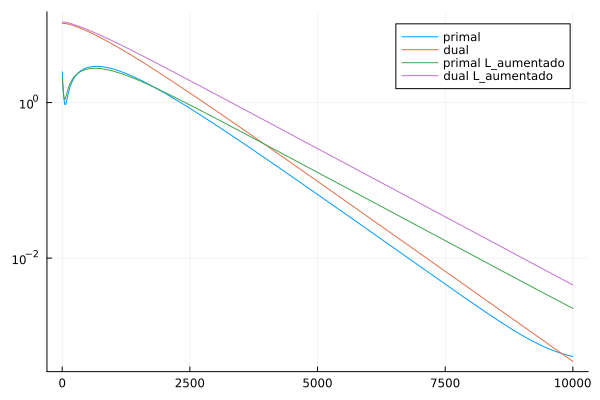

In [17]:
# modelo como un juego de suma cero con lagrangeano aumentado
# Jugador 1: busca minimizar L mediante el metodo del gradiente sobre las variables x
# Jugador 2: busca maximizar L mediante el metodo del gradiente sobre las variables λ
paso_primal = 0.001
paso_dual = 0.001
nt = 10000
x_paso = randn(n)
λ_paso = -rand()
L(x,λ) = sum(sum(0.5*a.*x.^2 .+ b.*x) - λ*(sum(x)-1) + 0.1*(sum(x)-1)^2 )
gr_error_primal = ones(nt)
gr_error_dual = ones(nt)
gr_payoff = zeros(nt)
for k = 1:nt
    f(x) = L(x,λ_paso)
    df = ForwardDiff.gradient(f,x_paso)
    x_paso -= df*paso_primal
    g(λ) = L(x_paso,λ)
    dg = ForwardDiff.derivative(g,λ_paso)
    λ_paso += dg*paso_dual
    gr_error_primal[k] = norm(x_paso-xopt)
    gr_error_dual[k] = abs(λ_paso-λopt)
    gr_payoff[k] = L(x_paso,λ_paso)
end
plot!(gr_error_primal,label="primal L_aumentado",yaxis = :log10)
plot!(gr_error_dual, label="dual L_aumentado",yaxis = :log10)